# Under Construction

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import cftime
import nc_time_axis
import sys
import calendar
import re
sys.path.append('C:/Users/madel/Code/GeoNorth/Observational_data')

from obs_utils import *

## Variable and Site settings

In [2]:
# Input the site ID and goal time length here

site = "TVC"         # BC, TVC, HC, IQ, SC

ctsm_start = cftime.DatetimeNoLeap(1995, 1, 1, has_year_zero=True)
ctsm_end   = cftime.DatetimeNoLeap(2014, 12, 31, has_year_zero=True)

# SOIL TEMP

In [3]:
vari = "TSOI"  #SNOW_DEPTH, H2OSOI, TSOI
directory_path = f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/raw/{vari}_ALL"
times, values, depths = pull_files_dupe(directory_path)

check that time shapes

In [4]:
check_shapes(times)

Index 0: (186326,)
Index 1: (163014,)
Index 2: (23312,)
Index 3: (163014,)
Index 4: (163014,)
Index 5: (23312,)
Index 6: (186326,)
Index 7: (23312,)
Index 8: (163014,)
Index 9: (186326,)
Index 10: (23312,)
Index 11: (163014,)
Index 12: (23312,)
Index 13: (163014,)
Index 14: (163014,)
Index 15: (23312,)


standardize all the time lengths

In [5]:
all_times = []
all_values = []

for x in range(0,len(times)):
    new_time, new_values = extend_time_and_values(
        times[x], values[x], ctsm_start, ctsm_end, freq="30T"
    )
    all_times.append(new_time)
    all_values.append(new_values)


check shapes and depths

In [6]:
check_shapes(all_times)
check_shapes(all_values)
print(depths)

All arrays match: (350353,)
All arrays match: (350353,)
[10.0, 104.0, 10.1, 10.2, 116.0, 117.0, 20.0, 20.1, 20.2, 30.0, 30.1, 30.2, 5.0, 50.0, 50.1, 90.0]


In [7]:
for i, (v, d) in enumerate(zip(all_values, depths)):
    print(f"[{i}] depth={d} non-nan={np.sum(~np.isnan(v))}")

[0] depth=10.0 non-nan=186326
[1] depth=104.0 non-nan=163014
[2] depth=10.1 non-nan=23312
[3] depth=10.2 non-nan=163014
[4] depth=116.0 non-nan=163014
[5] depth=117.0 non-nan=23312
[6] depth=20.0 non-nan=186326
[7] depth=20.1 non-nan=23312
[8] depth=20.2 non-nan=163014
[9] depth=30.0 non-nan=186326
[10] depth=30.1 non-nan=23312
[11] depth=30.2 non-nan=163014
[12] depth=5.0 non-nan=23312
[13] depth=50.0 non-nan=163014
[14] depth=50.1 non-nan=163014
[15] depth=90.0 non-nan=23312


In [8]:
data_2d = np.column_stack(all_values)

print(data_2d.shape)

(350353, 16)


In [9]:
ds_obs = make_obs_ds(vari, data_2d, all_times[0], site, "°C", depths)
ds_obs

<xarray.Dataset> Size: 48MB
Dimensions:  (time: 350353, depth: 16)
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 10.0 104.0 10.1 10.2 ... 5.0 50.0 50.1 90.0
Data variables:
    TSOI     (time, depth) float64 45MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    site:     TVC
    source:   GWF observed

In [10]:
def plot_soil_temp_depths(ds):
    fig, ax = plt.subplots(figsize=(14, 5))
    for depth in ds["depth"].values:
        ax.plot(ds["time"].values, ds[f"{vari}"].sel(depth=depth).values, label=f"{depth} m")
    ax.legend(loc="upper right")
    plt.show()

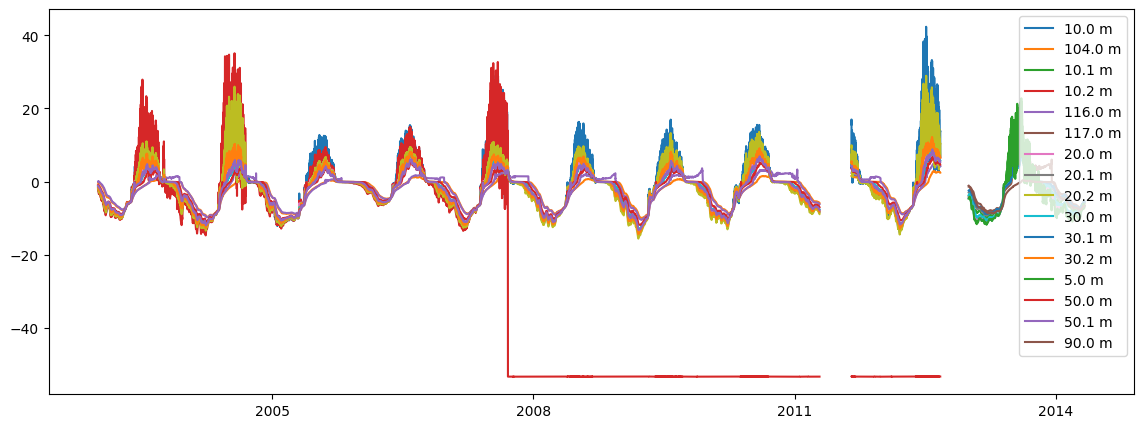

In [11]:
plot_soil_temp_depths(ds_obs)

In [12]:
ds_obs

<xarray.Dataset> Size: 48MB
Dimensions:  (time: 350353, depth: 16)
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 10.0 104.0 10.1 10.2 ... 5.0 50.0 50.1 90.0
Data variables:
    TSOI     (time, depth) float64 45MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    site:     TVC
    source:   GWF observed

In [13]:
ds_obs.to_netcdf(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")


In [14]:

# Load — one line back to xarray
ds_test = xr.open_dataset(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")
ds_test

<xarray.Dataset> Size: 48MB
Dimensions:  (time: 350353, depth: 16)
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 10.0 104.0 10.1 10.2 ... 5.0 50.0 50.1 90.0
Data variables:
    TSOI     (time, depth) float64 45MB ...
Attributes:
    site:     TVC
    source:   GWF observed

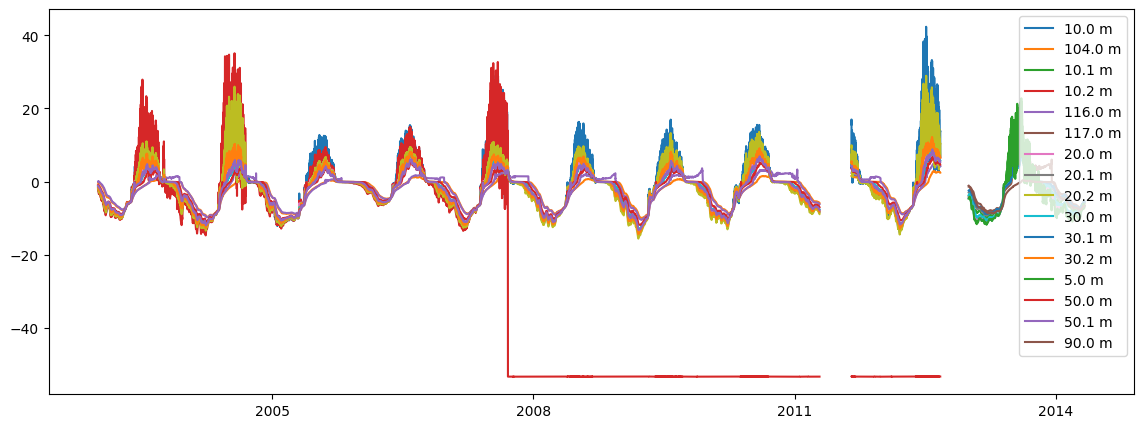

In [15]:
plot_soil_temp_depths(ds_test)

# SOIL MOISTURE

In [16]:
vari = "H2OSOI"  #SNOW_DEPTH, H2OSOI, TSOI
directory_path = f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/raw/{vari}"
times, values, depths = pull_files_dupe(directory_path)

In [17]:
check_shapes(times)

All arrays match: (186326,)


In [18]:
all_times = []
all_values = []

for x in range(0,len(times)):
    new_time, new_values = extend_time_and_values(
        times[x], values[x], ctsm_start, ctsm_end, freq="30T"
    )
    all_times.append(new_time)
    all_values.append(new_values)


In [19]:
check_shapes(all_times)
check_shapes(all_values)
print(depths)

All arrays match: (350353,)
All arrays match: (350353,)
[15.0, 8.0]


In [20]:
data_2d = np.column_stack(all_values)

print(data_2d.shape)

(350353, 2)


In [21]:
ds_obs = make_obs_ds(vari, data_2d, all_times[0], site, "mm3/mm3", depths)
ds_obs

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 350353, depth: 2)
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 16B 15.0 8.0
Data variables:
    H2OSOI   (time, depth) float64 6MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    site:     TVC
    source:   GWF observed

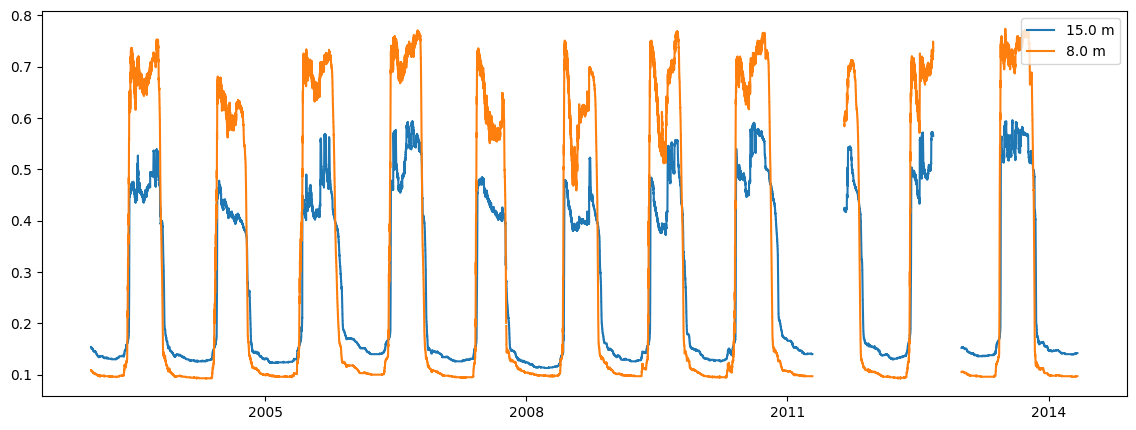

In [22]:
plot_soil_temp_depths(ds_obs)

In [23]:
ds_obs

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 350353, depth: 2)
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 16B 15.0 8.0
Data variables:
    H2OSOI   (time, depth) float64 6MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    site:     TVC
    source:   GWF observed

In [24]:
ds_obs.to_netcdf(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")


In [25]:

# Load — one line back to xarray
ds_test = xr.open_dataset(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")
ds_test

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 350353, depth: 2)
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 16B 15.0 8.0
Data variables:
    H2OSOI   (time, depth) float64 6MB ...
Attributes:
    site:     TVC
    source:   GWF observed

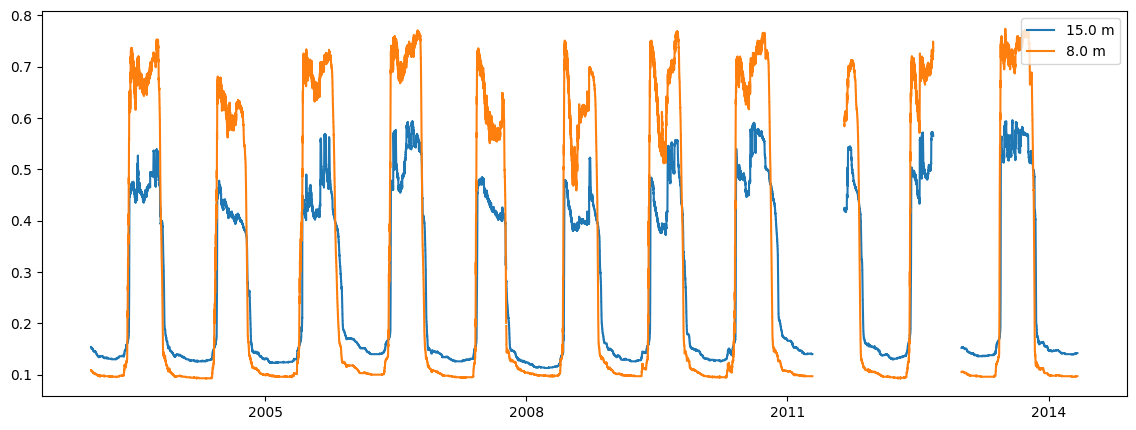

In [26]:
plot_soil_temp_depths(ds_test)

# SNOW DEPTH

In [27]:
vari = "SNOW_DEPTH"  #SNOW_DEPTH, H2OSOI, TSOI
directory_path = f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/raw/{vari}"
times, values, depths = pull_files_num(directory_path)

In [28]:
check_shapes(times)

Index 0: (87590,)
Index 1: (34844,)


In [29]:
all_times = []
all_values = []

for x in range(0,len(times)):
    new_time, new_values = extend_time_and_values(
        times[x], values[x], ctsm_start, ctsm_end, freq="30T"
    )
    all_times.append(new_time)
    all_values.append(new_values)


In [30]:
check_shapes(all_times)
check_shapes(all_values)
print(depths)

All arrays match: (350353,)
All arrays match: (350353,)
[0.0, 1.0]


In [31]:
data_2d = np.column_stack(all_values)

print(data_2d.shape)

(350353, 2)


In [32]:
ds_obs = make_obs_ds(vari, data_2d, all_times[0], site, "cm", depths)
ds_obs

<xarray.Dataset> Size: 8MB
Dimensions:     (time: 350353, depth: 2)
Coordinates:
  * time        (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth       (depth) float64 16B 0.0 1.0
Data variables:
    SNOW_DEPTH  (time, depth) float64 6MB nan nan nan nan ... nan nan nan nan
Attributes:
    site:     TVC
    source:   GWF observed

In [ ]:
def plot_soil_temp_depths(ds):
    fig, ax = plt.subplots(figsize=(14, 5))
    for depth in ds["depth"].values:
        ax.plot(ds["time"].values, ds[f"{vari}"].sel(depth=depth).values, label=f"{depth}")
    ax.legend(loc="upper right")
    plt.show()

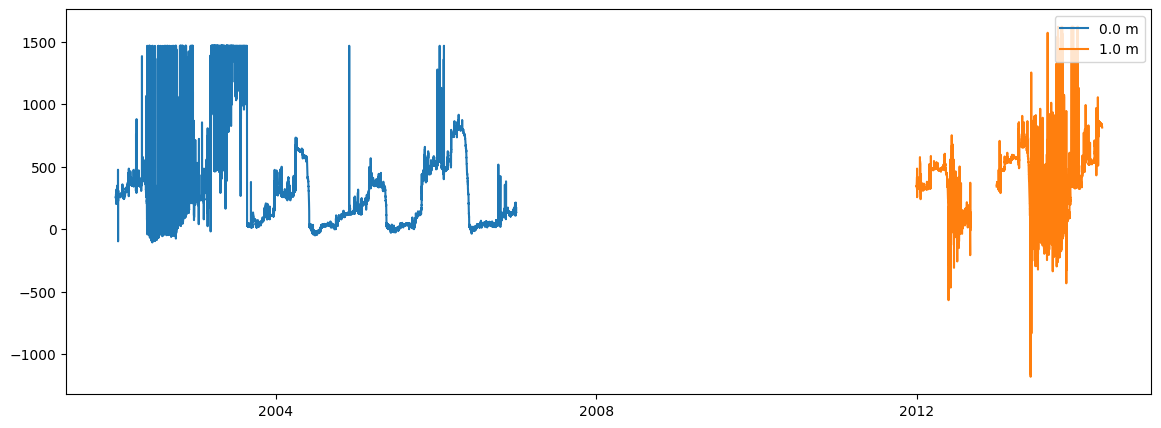

In [34]:
plot_soil_temp_depths(ds_obs)

In [35]:
ds_obs

<xarray.Dataset> Size: 8MB
Dimensions:     (time: 350353, depth: 2)
Coordinates:
  * time        (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth       (depth) float64 16B 0.0 1.0
Data variables:
    SNOW_DEPTH  (time, depth) float64 6MB nan nan nan nan ... nan nan nan nan
Attributes:
    site:     TVC
    source:   GWF observed

In [36]:
ds_obs.to_netcdf(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")


In [37]:

# Load — one line back to xarray
ds_test = xr.open_dataset(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")
ds_test

<xarray.Dataset> Size: 8MB
Dimensions:     (time: 350353, depth: 2)
Coordinates:
  * time        (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth       (depth) float64 16B 0.0 1.0
Data variables:
    SNOW_DEPTH  (time, depth) float64 6MB ...
Attributes:
    site:     TVC
    source:   GWF observed

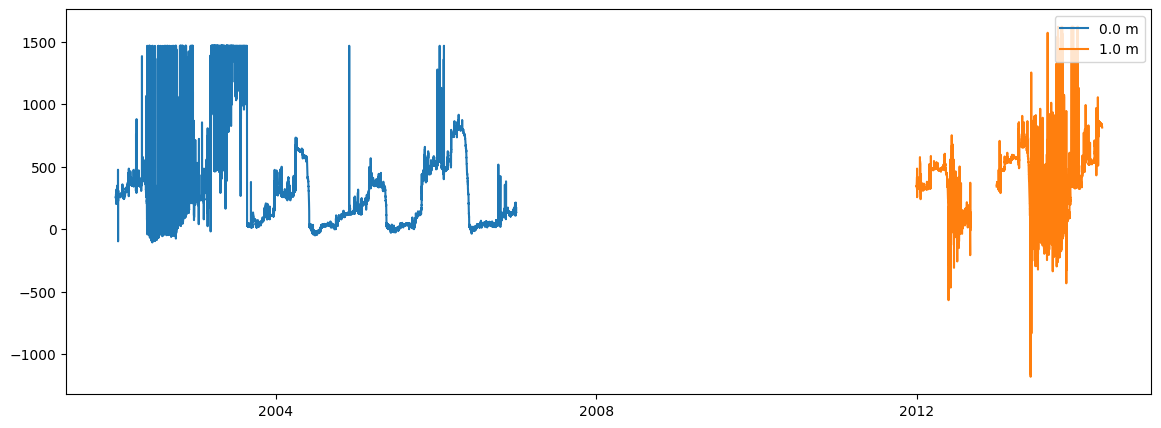

In [38]:
plot_soil_temp_depths(ds_test)